# Campione d'inverno e scudetto

Due domande, sui dati veri della Serie A.

1. Qual è la probabilità che il campione d'inverno vinca lo scudetto? Il calcolo è fatto all'inverno, cioè a fine girone di andata.
2. E l'Inter, da campione d'inverno, che probabilità ha?

I dati arrivano già puliti da `data/silver/` (la pipeline è negli script, vedi README). Qui c'è solo l'analisi.

### Librerie

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

## I dati

Una stagione per file in `data/silver/`, con le sole colonne che servono: data, squadre, gol. Li carico in un dizionario `campionati`, chiave = stagione.

In [2]:
# Carico le stagioni pulite da data/silver/: chiave = stagione, valore = DataFrame.
from pathlib import Path

SILVER = Path("../data/silver")
campionati = {
    f.stem.replace("I1_", ""): pd.read_csv(f)
    for f in sorted(SILVER.glob("I1_*.csv"))
}
print("Stagioni caricate:", len(campionati))

Stagioni caricate: 33


## Domanda 1 - la probabilità storica

Quante volte, dal 1993/94 a oggi, il campione d'inverno ha poi vinto lo scudetto?

Per ogni stagione ricostruisco la classifica fino alla fine del girone di andata (l'inverno), prendo il primo, e guardo se è lo stesso che vince a fine stagione.

In [3]:
def prepara_partite(df):
    """Colonne utili, date parsate, ordine cronologico, righe incomplete scartate."""
    m = df[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG"]].copy()
    m["Date"] = pd.to_datetime(m["Date"], format="mixed", dayfirst=True)
    m["FTHG"] = pd.to_numeric(m["FTHG"], errors="coerce")
    m["FTAG"] = pd.to_numeric(m["FTAG"], errors="coerce")
    return m.dropna().sort_values("Date").reset_index(drop=True)


def classifica(partite):
    """Classifica vettorializzata (GP, GF, GA, GD, Pts), ordinata per Pts, GD, GF."""
    casa = partite[["HomeTeam", "FTHG", "FTAG"]].rename(
        columns={"HomeTeam": "team", "FTHG": "gf", "FTAG": "ga"})
    trasferta = partite[["AwayTeam", "FTAG", "FTHG"]].rename(
        columns={"AwayTeam": "team", "FTAG": "gf", "FTHG": "ga"})
    lungo = pd.concat([casa, trasferta], ignore_index=True)
    lungo["pts"] = (lungo["gf"] > lungo["ga"]) * 3 + (lungo["gf"] == lungo["ga"]) * 1
    tab = lungo.groupby("team").agg(
        GP=("pts", "size"), GF=("gf", "sum"), GA=("ga", "sum"), Pts=("pts", "sum"))
    tab["GD"] = tab["GF"] - tab["GA"]
    return tab.sort_values(["Pts", "GD", "GF"], ascending=False)


def istantanee_stagione(df):
    """Classifica del campione d'inverno (fine girone di andata) e finale."""
    m = prepara_partite(df)
    n_squadre = pd.concat([m["HomeTeam"], m["AwayTeam"]]).nunique()
    apparizioni = pd.concat([
        pd.DataFrame({"team": m["HomeTeam"].values, "partita": m.index}),
        pd.DataFrame({"team": m["AwayTeam"].values, "partita": m.index}),
    ]).sort_values("partita")
    apparizioni["giocate"] = apparizioni.groupby("team").cumcount() + 1
    fine_andata = apparizioni.loc[apparizioni["giocate"] == n_squadre - 1, "partita"].max()
    return classifica(m[m.index <= fine_andata]), classifica(m)


def costruisci_dataset(campionati):
    """Un record per stagione: campione d'inverno, distacco sul 2deg, GD, scudetto."""
    righe = []
    for stagione, df in campionati.items():
        inverno, finale = istantanee_stagione(df)
        righe.append({
            "Team": inverno.index[0],
            "Season": stagione,
            "GapOnSecond": int(inverno.iloc[0]["Pts"] - inverno.iloc[1]["Pts"]),
            "GD": int(inverno.iloc[0]["GD"]),
            "WonScudetto": int(inverno.index[0] == finale.index[0]),
        })
    return pd.DataFrame(righe)

In [4]:
righe = []
for stagione, df in campionati.items():
    inverno, finale = istantanee_stagione(df)
    righe.append((stagione, inverno.index[0], finale.index[0], inverno.index[0] == finale.index[0]))

res = pd.DataFrame(righe, columns=["season", "winter", "final", "same"]).sort_values("season").reset_index(drop=True)
print(res)
print("\nP(scudetto | campione d'inverno) =", res["same"].mean())

   season      winter     final   same
0    0001        Roma      Roma   True
1    0102        Roma  Juventus  False
2    0203       Milan  Juventus  False
3    0304        Roma     Milan  False
4    0405    Juventus  Juventus   True
5    0506    Juventus  Juventus   True
6    0607       Inter     Inter   True
7    0708       Inter     Inter   True
8    0809       Inter     Inter   True
9    0910       Inter     Inter   True
10   1011       Milan     Milan   True
11   1112    Juventus  Juventus   True
12   1213    Juventus  Juventus   True
13   1314    Juventus  Juventus   True
14   1415    Juventus  Juventus   True
15   1516      Napoli  Juventus  False
16   1617    Juventus  Juventus   True
17   1718      Napoli  Juventus  False
18   1819    Juventus  Juventus   True
19   1920    Juventus  Juventus   True
20   2021       Milan     Inter  False
21   2122       Inter     Milan  False
22   2223      Napoli    Napoli   True
23   2324       Inter     Inter   True
24   2425      Napoli    

## Esplorativa

Prima dei modelli, qualche numero descrittivo:
- quante stagioni e quante squadre;
- quanti campioni d'inverno e quanti campioni finali distinti;
- la conversione campione d'inverno -> scudetto, per squadra;
- chi ha vinto lo scudetto **senza** essere campione d'inverno.

In [5]:
tutte_le_squadre = set()
for df in campionati.values():
    tutte_le_squadre |= set(df["HomeTeam"]) | set(df["AwayTeam"])

print("Stagioni osservate:", len(res))
print("Squadre distinte (tutte le stagioni):", len(tutte_le_squadre))
print("Campioni d'inverno distinti:", res["winter"].nunique())
print("Campioni finali distinti:", res["final"].nunique())

conv = res.groupby("winter").agg(
    volte_inverno=("same", "size"),
    poi_campione=("same", "sum"),
)
conv["quota"] = (conv["poi_campione"] / conv["volte_inverno"]).round(2)
conv = conv.sort_values(["volte_inverno", "poi_campione"], ascending=False)
print("\nConversione campione d'inverno -> scudetto, per squadra:")
print(conv)

rimonte = res.loc[~res["same"], ["season", "winter", "final"]]
print(f"\nScudetto senza essere campione d'inverno: {len(rimonte)} stagioni")
print(rimonte.to_string(index=False))
print("\nRimonte per squadra:")
print(rimonte["final"].value_counts().to_string())

Stagioni osservate: 33
Squadre distinte (tutte le stagioni): 53
Campioni d'inverno distinti: 6
Campioni finali distinti: 6

Conversione campione d'inverno -> scudetto, per squadra:
            volte_inverno  poi_campione  quota
winter                                        
Juventus               13            12   0.92
Inter                   7             6   0.86
Milan                   5             3   0.60
Napoli                  4             2   0.50
Roma                    3             1   0.33
Fiorentina              1             0   0.00

Scudetto senza essere campione d'inverno: 9 stagioni
season     winter    final
  0102       Roma Juventus
  0203      Milan Juventus
  0304       Roma    Milan
  1516     Napoli Juventus
  1718     Napoli Juventus
  2021      Milan    Inter
  2122      Inter    Milan
  9899 Fiorentina    Milan
  9900   Juventus    Lazio

Rimonte per squadra:
final
Juventus    4
Milan       3
Inter       1
Lazio       1


## Tavola di contingenza

La domanda mette a confronto due probabilita': scudetto **se** campione d'inverno
contro scudetto **se non** campione d'inverno. La guardiamo su tutte le coppie
squadra-stagione, con il test esatto di Fisher (adatto ai conteggi piccoli).

In [6]:
from scipy.stats import fisher_exact, chi2_contingency
from statsmodels.stats.proportion import proportion_confint

# coppie squadra-stagione totali
n_ts = sum(len(set(df["HomeTeam"]) | set(df["AwayTeam"])) for df in campionati.values())

a = int(res["same"].sum())     # campione d'inverno e poi scudetto
b = len(res) - a               # campione d'inverno ma non scudetto
c = b                          # non camp. d'inverno ma scudetto (1 campione per stagione)
d = n_ts - a - b - c           # non camp. d'inverno e non scudetto

tabella = pd.DataFrame(
    [[a, b], [c, d]],
    index=["camp. d'inverno", "non camp. d'inverno"],
    columns=["scudetto", "no scudetto"],
)
print("Tavola di contingenza (coppie squadra-stagione) - frequenze:")
print(tabella)

perc = (tabella.div(tabella.sum(axis=1), axis=0) * 100).round(1)
print("\n% per riga  (= P(esito | riga)):")
print(perc)

lo, hi = proportion_confint(a, a + b, method="wilson")
print(f"\nP(scudetto | camp. d'inverno)     = {a / (a + b):.3f}  IC95% Wilson [{lo:.2f}, {hi:.2f}]")
print(f"P(scudetto | NON camp. d'inverno) = {c / (c + d):.4f}")

odds, p_f = fisher_exact([[a, b], [c, d]])
chi2, p_chi2, dof, attesi = chi2_contingency([[a, b], [c, d]])
print(f"\nFisher esatto: odds ratio = {odds:.1f}, p-value = {p_f:.2e}")
print(f"Chi-quadro:    {chi2:.1f} (dof={dof}), p-value = {p_chi2:.2e}")
print(f"Frequenza attesa minima = {attesi.min():.1f}  -> < 5: il test affidabile e' Fisher.")

Tavola di contingenza (coppie squadra-stagione) - frequenze:
                     scudetto  no scudetto
camp. d'inverno            24            9
non camp. d'inverno         9          596

% per riga  (= P(esito | riga)):
                     scudetto  no scudetto
camp. d'inverno          72.7         27.3
non camp. d'inverno       1.5         98.5

P(scudetto | camp. d'inverno)     = 0.727  IC95% Wilson [0.56, 0.85]
P(scudetto | NON camp. d'inverno) = 0.0149

Fisher esatto: odds ratio = 176.6, p-value = 6.08e-29
Chi-quadro:    309.4 (dof=1), p-value = 2.91e-69
Frequenza attesa minima = 1.7  -> < 5: il test affidabile e' Fisher.


## Domanda 2 - e l'Inter?

La probabilità storica è una media. Qui proviamo a stimarla a partire da quanto era forte il campione d'inverno: differenza reti e distacco sul secondo a metà stagione. Poi applichiamo il modello al caso dell'Inter.

In [7]:
setDati = costruisci_dataset(campionati)
print(f"Dataset creato con {len(setDati)} record storici.")
print(setDati)

Dataset creato con 33 record storici.
          Team Season  GapOnSecond  GD  WonScudetto
0         Roma   0001            6  20            1
1         Roma   0102            4  17            0
2        Milan   0203            3  23            0
3         Roma   0304            0  29            0
4     Juventus   0405            2  23            1
5     Juventus   0506           10  31            1
6        Inter   0607            9  25            1
7        Inter   0708            5  30            1
8        Inter   0809            3  18            1
9        Inter   0910            6  24            1
10       Milan   1011            4  17            1
11    Juventus   1112            1  20            1
12    Juventus   1213            5  27            1
13    Juventus   1314            8  34            1
14    Juventus   1415            5  33            1
15      Napoli   1516            4  25            0
16    Juventus   1617            1  24            1
17      Napoli   1718     

# ML: Classificazione

In [8]:
features = ["GD", "GapOnSecond"]
X = setDati[features]
y = setDati["WonScudetto"]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=42)

In [10]:
model = LogisticRegression()

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:,1]
preds = model.predict(X_test)

from sklearn.metrics import accuracy_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))

Accuracy: 0.5714285714285714
ROC AUC: 0.5833333333333334


In [11]:
X = setDati.drop(columns=["Team", "Season", "WonScudetto"])
y = setDati["WonScudetto"]

In [12]:
loo = LeaveOneOut()

model = LogisticRegression()

y_true = []
y_pred = []
y_prob = []

In [13]:
for train_index, test_index in loo.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    model.fit(X_train, y_train)

    pred = model.predict(X_test)[0]
    prob = model.predict_proba(X_test)[0][1]

    y_pred.append(pred)
    y_prob.append(prob)
    y_true.append(y_test.values[0])

In [14]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("ROC AUC:", roc_auc_score(y_true, y_prob))

Accuracy: 0.6666666666666666
ROC AUC: 0.5787037037037037


In [15]:
print("Probabilità media scudetto campione d'inverno:", np.mean(y_prob))

Probabilità media scudetto campione d'inverno: 0.728102692542545


### L'Inter 2025/26: una prova out-of-sample

La 25/26 ormai è osservata: l'Inter, campione d'inverno, ha vinto lo scudetto.
Non c'è niente da "prevedere". Facciamo però una prova onesta: nascondiamo la
25/26, addestriamo il modello sulle altre stagioni, e vediamo che probabilità
avrebbe dato all'Inter da confrontare con la realtà.

In [16]:
# Prova out-of-sample: modello addestrato su tutte le stagioni TRANNE la 25/26,
# poi predice l'Inter 25/26 con le sue statistiche vere all'inverno.
inter = setDati[setDati["Season"] == "2526"]
altre = setDati[setDati["Season"] != "2526"]

modello_oos = LogisticRegression().fit(altre[features], altre["WonScudetto"])
prob = modello_oos.predict_proba(inter[features])[0][1]

print(f"Inter 25/26 all'inverno: GapOnSecond={int(inter.iloc[0]['GapOnSecond'])}, GD={int(inter.iloc[0]['GD'])}")
print(f"Probabilita' out-of-sample di vincere lo scudetto: {prob:.1%}")
print(f"Esito reale: {'vinto' if int(inter.iloc[0]['WonScudetto']) else 'non vinto'}")

Inter 25/26 all'inverno: GapOnSecond=3, GD=25
Probabilita' out-of-sample di vincere lo scudetto: 69.8%
Esito reale: vinto


## Bontà del modello

Con così pochi dati la valutazione onesta è quella out-of-fold: uso le predizioni della cross-validation Leave-One-Out (ogni stagione predetta da un modello che non l'ha vista). ROC e matrice di confusione su quelle.

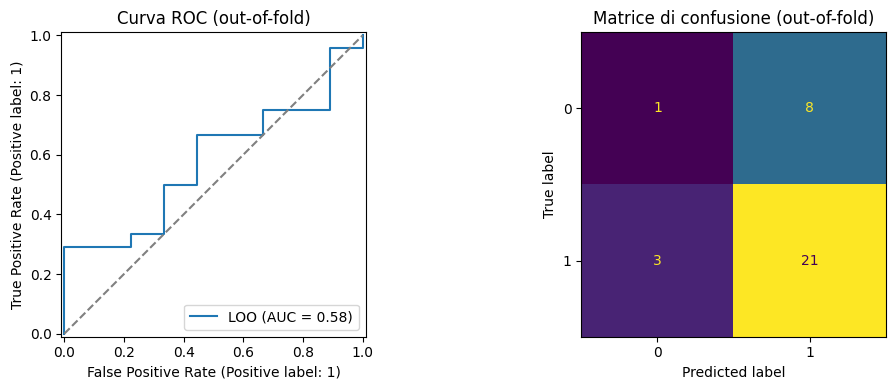

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax[0], name="LOO")
ax[0].plot([0, 1], [0, 1], "--", color="grey")
ax[0].set_title("Curva ROC (out-of-fold)")

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax[1], colorbar=False)
ax[1].set_title("Matrice di confusione (out-of-fold)")

plt.tight_layout()
plt.show()

## Logistica in ottica statistica

A n=32 la lettura utile e' descrittiva, non predittiva. Stessa regressione
logistica, ma guardata sui **parametri**: coefficienti, p-value, odds ratio
(`exp` del coefficiente), pseudo-R^2. Con cosi' pochi dati gli intervalli sono
ampi: si leggono segno e ordine di grandezza, non certezze.

In [18]:
import numpy as np
import statsmodels.api as sm

X_sm = sm.add_constant(X)
logit = sm.Logit(y, X_sm).fit()
print(logit.summary())
print("\nOdds ratio (exp dei coefficienti):")
print(np.exp(logit.params).round(3))

Optimization terminated successfully.
         Current function value: 0.503640
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            WonScudetto   No. Observations:                   33
Model:                          Logit   Df Residuals:                       30
Method:                           MLE   Df Model:                            2
Date:                Tue, 16 Jun 2026   Pseudo R-squ.:                  0.1405
Time:                        13:28:05   Log-Likelihood:                -16.620
converged:                       True   LL-Null:                       -19.336
Covariance Type:            nonrobust   LLR p-value:                   0.06612
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1334      1.463      0.091      0.927      -2.733       3.000
GapOnSecond     0.4437    

## In sintesi

- Storicamente il campione d'inverno vince lo scudetto circa il 73% delle volte (24 su 33).
- Conta soprattutto il distacco sul secondo a metà stagione, non la differenza reti.
- L'Inter 2025/26, campione d'inverno, ha vinto; un modello out-of-sample le dava ~70% (dalla parte giusta, ma quasi pari al tasso storico).

33 stagioni sono comunque poche: è una tendenza, non una legge. Da qui le altre domande - altre tecniche statistiche e più dati (vedi README).